<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hackathons/dsn/000_DSN_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
def get_data(filename):
    dataset_path = os.path.join( filename)
    return pd.read_csv(dataset_path)

In [ ]:
df = get_data("Housing_dataset_train.csv")

In [ ]:
df.head()

,ID,loc,title,bedroom,bathroom,parking_space,price
0,3583,Katsina,Semi-detached duplex,2.0,2.0,1.0,1149999.565
1,2748,Ondo,Apartment,NaN,2.0,4.0,1672416.689
2,9261,Ekiti,NaN,7.0,5.0,NaN,3364799.814
3,2224,Anambra,Detached duplex,5.0,2.0,4.0,2410306.756
4,10300,Kogi,Terrace duplex,NaN,5.0,6.0,2600700.898


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             14000 non-null  int64  
 1   loc            12187 non-null  object 
 2   title          12278 non-null  object 
 3   bedroom        12201 non-null  float64
 4   bathroom       12195 non-null  float64
 5   parking_space  12189 non-null  float64
 6   price          14000 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 765.8+ KB


In [ ]:
df.describe()

,ID,bedroom,bathroom,parking_space,price
count,14000.000000,12201.000000,12195.000000,12189.000000,1.400000e+04
mean,4862.700357,4.308171,3.134235,3.169825,2.138082e+06
std,3818.348214,2.441165,2.035950,1.599415,1.083057e+06
min,0.000000,1.000000,1.000000,1.000000,4.319673e+05
25%,1672.750000,2.000000,1.000000,2.000000,1.393990e+06
50%,3527.000000,4.000000,2.000000,3.000000,1.895223e+06
75%,8011.250000,6.000000,5.000000,4.000000,2.586699e+06
max,12999.000000,9.000000,7.000000,6.000000,1.656849e+07


The count of ID is 14000 but it's maximum value is 12999, there seems to be some duplication in that column as it should identify one data entry and as such, its maximum value should be equal to the count.
Going by this assumption, we'll check to see if the duplication is across the columns of the entry or if it's just the ID column.

In [ ]:
df[df.duplicated(subset=['ID'],keep=False)].sort_values(by="ID").head(10)

,ID,loc,title,bedroom,bathroom,parking_space,price
12637,0,Kaduna,Townhouse,7.0,4.0,3.0,2468007.621
8591,0,Benue,Penthouse,5.0,2.0,1.0,2404653.558
8688,0,Borno,Apartment,4.0,1.0,NaN,1087381.444
9553,1,NaN,Penthouse,5.0,1.0,4.0,1634589.219
54,1,Niger,Semi-detached duplex,4.0,2.0,2.0,1476299.188
10675,1,Akwa Ibom,NaN,5.0,1.0,6.0,2772552.436
6656,2,Ebonyi,Flat,9.0,5.0,4.0,2343938.473
4118,2,Gombe,Detached duplex,5.0,2.0,1.0,1897400.277
8728,3,Imo,Semi-detached duplex,1.0,1.0,1.0,1039983.150
661,3,Jigawa,NaN,5.0,7.0,5.0,2447296.782


It seems only the ID column was duplicated as entries with the same ID hold different values. We'll remove the column.

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'bedroom'}>],
       [<Axes: title={'center': 'bathroom'}>,
        <Axes: title={'center': 'parking_space'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >]], dtype=object)

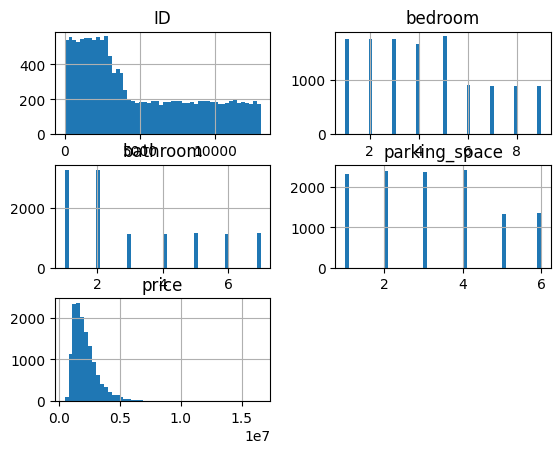

In [ ]:
df.hist(bins=50)

In [ ]:
df.head()

,ID,loc,title,bedroom,bathroom,parking_space,price
0,3583,Katsina,Semi-detached duplex,2.0,2.0,1.0,1149999.565
1,2748,Ondo,Apartment,NaN,2.0,4.0,1672416.689
2,9261,Ekiti,NaN,7.0,5.0,NaN,3364799.814
3,2224,Anambra,Detached duplex,5.0,2.0,4.0,2410306.756
4,10300,Kogi,Terrace duplex,NaN,5.0,6.0,2600700.898


In [ ]:
df.corr(numeric_only=True)

,ID,bedroom,bathroom,parking_space,price
ID,1.000000,0.230474,0.345121,0.165160,0.167093
bedroom,0.230474,1.000000,0.227417,0.111095,0.529145
bathroom,0.345121,0.227417,1.000000,0.178497,0.221544
parking_space,0.165160,0.111095,0.178497,1.000000,0.109211
price,0.167093,0.529145,0.221544,0.109211,1.000000


### Get the data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
seed = 99

The number of bedrooms correlates more with the price hence for our split, we'll want to make sure our test data is representative of all the various numbers of bedrooms

In [ ]:
# introduce a new column to handle bedroom na values for splitting sake
max = df["bedroom"].max() + 1
df["bedroom_cat"] = df["bedroom"].fillna(max)

In [ ]:
strat_train_val_set, strat_test_set = train_test_split(df, stratify=df["bedroom_cat"], test_size=0.15)
strat_train_set, strat_val_set = train_test_split(strat_train_val_set, stratify=strat_train_val_set["bedroom_cat"], test_size=0.2)

In [ ]:
# dropping the bedroom cat attribute since it was only useful for splitting
for set_ in (strat_test_set, strat_train_set, strat_val_set):
    set_.drop(columns=["bedroom_cat"], inplace=True)

In [ ]:
# def remove_irrelevant_columns(df):
#     return df.drop(columns=["ID"])

def get_Xy_data(df):
#     df = remove_irrelevant_columns(df)
    x_cols = ["loc", "title", "bedroom", "bathroom", "parking_space"]
    y_col = "price"
    X_train = df[x_cols]
    y_train = df[y_col]
    return X_train, y_train

### Explore the Data

In [ ]:
from pandas.plotting import scatter_matrix

array([[<Axes: xlabel='bedroom', ylabel='bedroom'>,
        <Axes: xlabel='bathroom', ylabel='bedroom'>,
        <Axes: xlabel='parking_space', ylabel='bedroom'>,
        <Axes: xlabel='price', ylabel='bedroom'>],
       [<Axes: xlabel='bedroom', ylabel='bathroom'>,
        <Axes: xlabel='bathroom', ylabel='bathroom'>,
        <Axes: xlabel='parking_space', ylabel='bathroom'>,
        <Axes: xlabel='price', ylabel='bathroom'>],
       [<Axes: xlabel='bedroom', ylabel='parking_space'>,
        <Axes: xlabel='bathroom', ylabel='parking_space'>,
        <Axes: xlabel='parking_space', ylabel='parking_space'>,
        <Axes: xlabel='price', ylabel='parking_space'>],
       [<Axes: xlabel='bedroom', ylabel='price'>,
        <Axes: xlabel='bathroom', ylabel='price'>,
        <Axes: xlabel='parking_space', ylabel='price'>,
        <Axes: xlabel='price', ylabel='price'>]], dtype=object)

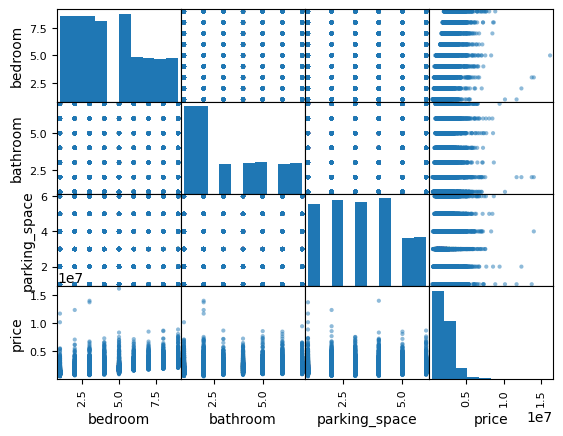

In [ ]:
cols = ["bedroom", "bathroom", "parking_space", "price"]
scatter_matrix(strat_train_set[cols])

In [ ]:
new_df = strat_train_set.copy()

In [ ]:
new_df["bathroom_per_room"] = new_df["bathroom"] / new_df["bedroom"]
new_df["park_space_per_room"] = new_df["parking_space"] / new_df["bedroom"]
new_df["bath_park_space"] = new_df["bathroom_per_room"] + new_df["park_space_per_room"]

In [ ]:
new_df

,ID,loc,title,bedroom,bathroom,parking_space,price,bathroom_per_room,park_space_per_room,bath_park_space
3678,4588,Osun,Flat,5.0,NaN,4.0,1899744.964,NaN,0.800000,NaN
4900,2190,Benue,NaN,1.0,2.0,3.0,3083399.474,2.000000,3.000000,5.000000
11536,7358,NaN,Detached duplex,7.0,2.0,4.0,3076811.000,0.285714,0.571429,0.857143
5001,9719,NaN,Semi-detached duplex,4.0,5.0,5.0,1580876.261,1.250000,1.250000,2.500000
5874,91,Osun,Terrace duplex,NaN,3.0,3.0,2451052.009,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
10792,2709,Zamfara,Detached duplex,NaN,2.0,1.0,1255366.984,NaN,NaN,NaN
12338,2927,Ekiti,Apartment,1.0,1.0,6.0,941263.430,1.000000,6.000000,7.000000
12624,12925,Abia,Penthouse,1.0,3.0,5.0,1388122.447,3.000000,5.000000,8.000000
10797,2204,Ogun,NaN,1.0,4.0,3.0,1488073.860,4.000000,3.000000,7.000000


In [ ]:
cols = ["bedroom", "bathroom", "parking_space", "price", "bathroom_per_room", "park_space_per_room", "bath_park_space"]
new_df[cols].corr()["price"]

bedroom                0.544019
bathroom               0.219256
parking_space          0.112014
price                  1.000000
bathroom_per_room     -0.205161
park_space_per_room   -0.294138
bath_park_space       -0.267405
Name: price, dtype: float64

### Prepare the Data

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
new_df = strat_train_set.copy()

In [ ]:
num_cols = ["bedroom", "bathroom", "parking_space"]
cat_cols = ["loc", "title"]

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# There may be no need for scaling as the attributes have similar scales

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

In [ ]:
class CustomAttribsAdder(BaseEstimator, TransformerMixin):
    def __init__(self, merge_loc_title=False):
        self.merge_loc_title = merge_loc_title
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if self.merge_loc_title:
            loc_title = X[:, loc_ix] + X[:, title_ix]
            return np.c_[X, loc_title]
        else:
            park_space_per_room = X[:, parking_space_ix] / X[:, bedrooms_ix]
            bathroom_per_room = X[:, bathrooms_ix] / X[:, bedrooms_ix]
            return np.c_[X, bathroom_per_room, park_space_per_room]

In [ ]:
bedrooms_ix, bathrooms_ix, parking_space_ix = 0, 1, 2
loc_ix, title_ix = 0, 1

In [ ]:
cat_pipeline = Pipeline([
    ("cat_imputer", SimpleImputer(strategy="most_frequent")),
    # ("cat_custom_attribs", CustomAttribsAdder(merge_loc_title=True)),
    ("cat_encoder", OneHotEncoder()),
])
num_pipeline = Pipeline([
    ("num_imputer", SimpleImputer()),
    ("num_custom_attribs", CustomAttribsAdder()),
    ("std_scaler", StandardScaler())

])

In [ ]:
full_pipeline = ColumnTransformer([
    ("num_pipeline", num_pipeline, num_cols),
    ("cat_pipeline", cat_pipeline, cat_cols),
])


### ShortList Promising Models

In [ ]:
def display_scores(scores):
    print(f"Mean Score: {scores.mean()}\n Std Deviation: {scores.std()}")


In [ ]:
def shortListModels(models, X_train, y_train):
    for model in models:
        print(f"Running {model}")
        # single short train
#         model = model_class()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_train)
        mse = mean_squared_error(y_train, y_pred)
        rmse = np.sqrt(mse) # single shot rmse

        print("single shot scores")
        display_scores(rmse)

#         model = model_class()
        # cross validate
        scores = cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error", cv=5)
        cv_rmse = np.sqrt(-scores) # cross validate rmse
        print("cross val scores")
        display_scores(cv_rmse)
        print("\n")



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
### Random Forest

In [ ]:
forest_reg = RandomForestRegressor()
linear_reg = LinearRegression()
# svm_reg = SVR(kernel='linear', C=1000.0)
tree_reg = DecisionTreeRegressor(max_features=28,
                    max_depth=30, min_samples_split=20, min_samples_leaf=1, random_state=seed)

In [ ]:
new_df = strat_train_set.copy()
X_train_prepared = full_pipeline.fit_transform(new_df)
y_train = new_df["price"]

In [ ]:
models = [linear_reg,  tree_reg]
shortListModels(models, X_train_prepared, y_train)

Running LinearRegression()
single shot scores
Mean Score: 544145.6117288892
 Std Deviation: 0.0
cross val scores
Mean Score: 547205.1327690714
 Std Deviation: 29554.983417477128


Running DecisionTreeRegressor(max_depth=30, max_features=28, min_samples_split=20,
                      random_state=99)
single shot scores
Mean Score: 462790.920053672
 Std Deviation: 0.0
cross val scores
Mean Score: 630029.9482097557
 Std Deviation: 29388.416873722217




The linearRegression model seems to be underfitting the model, as it is not regularized, this means the model is not powerful enough hence we should feed it with better features. So also for the support vector model.

Decision tree and random forest models are overfitting the training set as their training scores are a lot lower than the cross val scores. since random forest is an ensemble of decision trees, let's work on it.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
forest_param_grid = {
     "n_estimators": [3, 10, 30, 80, 100, 200],
     "max_depth": [32, 64, 72, 88, 99],
     "min_samples_split": [2, 5, 7, 13, 20, 33, 53],
     "min_samples_leaf": [1, 3, 5, 7, 9],
     "max_features":[2, 4, 6, 8, 0.3, "log2"],
     "bootstrap": [False, True],
     "random_state": [seed]
    }
forest_param_grid = [
    {"n_estimators": [94],
     "max_features": [28],
     "max_depth": [20, 22, 24, 26, 30, 32],
     "min_samples_split": [20],
     "min_samples_leaf": [1, 3, 5, 7, 9],
    },
]

In [ ]:
DecisionTreeRegressor()

In [ ]:
forest_param_grid

[{'n_estimators': [94],
  'max_features': [28],
  'max_depth': [20, 22, 24, 26, 30, 32],
  'min_samples_split': [20],
  'min_samples_leaf': [1, 3, 5, 7, 9]}]

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
random_search_fr = GridSearchCV(forest_reg, forest_param_grid,
                        scoring="neg_mean_squared_error",
                        return_train_score=True, cv=5)

In [ ]:
random_search_fr.fit(X_train_prepared, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_depth': [20, 22, 24, 26, 30, 32],
                          'max_features': [28],
                          'min_samples_leaf': [1, 3, 5, 7, 9],
                          'min_samples_split': [20], 'n_estimators': [94]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
random_search_fr.best_estimator_

RandomForestRegressor(max_depth=22, max_features=28, min_samples_split=20,
                      n_estimators=94)

In [ ]:
cvres = random_search_fr.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

592228.475126335 {'max_depth': 20, 'max_features': 28, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 94}
605274.5769845989 {'max_depth': 20, 'max_features': 28, 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 94}
618561.1359754367 {'max_depth': 20, 'max_features': 28, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 94}
631167.7664652383 {'max_depth': 20, 'max_features': 28, 'min_samples_leaf': 7, 'min_samples_split': 20, 'n_estimators': 94}
639036.3417907783 {'max_depth': 20, 'max_features': 28, 'min_samples_leaf': 9, 'min_samples_split': 20, 'n_estimators': 94}
587878.2217960367 {'max_depth': 22, 'max_features': 28, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 94}
604032.1373832285 {'max_depth': 22, 'max_features': 28, 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 94}
619350.7058154959 {'max_depth': 22, 'max_features': 28, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 94}
629432.21

In [ ]:
cat_encoder = full_pipeline.named_transformers_["cat_pipeline"]
cat_cols2 = cat_encoder.named_steps["cat_encoder"].categories_
cat_prepared_cols = list(cat_cols2[0]) + list(cat_cols2[1]) + list(cat_cols2[2])
extra_attribs = ["bath_per_room", "park_space_per_room"]
all_cols = num_cols + extra_attribs + cat_prepared_cols
sorted(zip(random_search_fr.best_estimator_.feature_importances_* 100, all_cols), reverse=True)

[(15.43673389188909, 'bedroom'),
 (14.903633156502133, 'Mansion'),
 (9.519533461751788, 'park_space_per_room'),
 (7.456293751413921, 'bath_per_room'),
 (5.717778117085186, 'Lagos'),
 (5.591654984661246, 'bathroom'),
 (5.047638363829856, 'parking_space'),
 (2.7002089785038033, 'LagosMansion'),
 (2.472163813797428, 'AnambraMansion'),
 (1.9821625506166012, 'Penthouse'),
 (1.4844002236674412, 'Apartment'),
 (1.3241093283572154, 'Bayelsa'),
 (1.0395566231898161, 'RiversMansion'),
 (0.9469067137904538, 'Rivers'),
 (0.8633655528421766, 'BayelsaMansion'),
 (0.7893866904135565, 'LagosFlat'),
 (0.7837228401356642, 'LagosPenthouse'),
 (0.702974152620881, 'Bungalow'),
 (0.6790958705338827, 'Cottage'),
 (0.6354303433727834, 'Akwa Ibom'),
 (0.6019423859590458, 'Flat'),
 (0.5877898750208621, 'OgunMansion'),
 (0.5805456375266288, 'Delta'),
 (0.4656422598783871, 'DeltaMansion'),
 (0.4480341702691857, 'LagosDetached duplex'),
 (0.4478733720639058, 'Ogun'),
 (0.44578779831464954, 'Detached duplex'),
 (0.

In [ ]:
random_search_fr.best_estimator_

In [ ]:
random_search_fr.best_score_

In [ ]:
import tensorflow
from tensorflow import keras

In [ ]:
X_val, y_val = get_Xy_data(strat_val_set)
X_val_prepared = full_pipeline.fit_transform(X_val)
X_train, y_train = get_Xy_data(strat_train_set)
X_train_prepared = full_pipeline.fit_transform(X_train)

In [ ]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=X_train_prepared.shape[1:]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1),
])

In [ ]:
# model.compile(optimizer="sgd", loss="mean_squared_error" )

In [ ]:
# opt = keras.optimizers.Adam(0.001 )

In [ ]:
model.compile(loss="mse", optimizer="sgd")

In [ ]:
y_t = y_train.to_numpy() /  1_000_000
y_v = y_val.to_numpy() / 1_000_000

In [ ]:
history = model.fit(X_train_prepared, y_t, epochs=200,
                    validation_data=(X_val_prepared, y_v))

Epoch 1/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2123 - val_loss: 0.3300
Epoch 2/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2140 - val_loss: 0.3227
Epoch 3/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2149 - val_loss: 0.3270
Epoch 4/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2089 - val_loss: 0.3280
Epoch 5/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2119 - val_loss: 0.3289
Epoch 6/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2115 - val_loss: 0.3335
Epoch 7/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2097 - val_loss: 0.3296
Epoch 8/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2112 - val_loss: 0.3344
Epoch 9/200
298/298 [==============================] - 1s 3ms/step - loss: 0.2097 - val_loss: 0.3408
Epoch 10/200
298/298 [==============================] - 1s 5ms/step - loss: 0.2083 - val_lo

In [ ]:
y_pred = model.predict(X_val_prepared)

75/75 [==============================] - 0s 2ms/step


In [ ]:
y_pred = model.predict(X_val_prepared)
np.c_[y_pred, y_v] * 1_000_000

array([[2725862.50305176, 2572345.527     ],
       [2528564.453125  , 2494350.095     ],
       [1540356.15921021, 1343557.471     ],
       ...,
       [1970715.04592896, 1868310.211     ],
       [1683471.56047821, 1498710.16      ],
       [1727934.12208557, 1654971.224     ]])

In [ ]:
score = mean_squared_error(y_v*1_000_000, y_pred*1_000_000)

In [ ]:
np.sqrt(score)

625469.5113673398